# Q1. What are the most common reasons for missing data in ETL pipelines?

## ANSWER
1) DATA ENTRY ERRORS
2) SYSTEM OR NETWORK FAILUERS
3) MISSING VALUES IN SOURCE SYSTEMS
4) ERRORS DURING DATA EXTRACTION ORTRANSFORMATION
5) OPTIONAL FIELDS LEFT BLANK BY USERS
6) DATA INTEGRETION ISSUES BETWEEN MULTIPLE SOURCES


# Q2. Why is blindly deleting rows with missing values considered a bad practice in ETL?

### ANSWER
## Q2. Why is blindly deleting rows with missing values considered a bad practice in ETL?

### Answer:
Blindly deleting rows with missing values is a bad practice because it:
- Reduces the size of the dataset.
- Causes loss of important information.
- Can introduce bias into the analysis.
- May reduce the accuracy of machine learning models and reports.

Therefore, missing values should be handled using appropriate techniques such as imputation or flagging instead of deleting all rows.

# Q3. Explain the difference between:

Listwise deletion

Column deletion

Also mention one scenario where each is appropriate.

### Answer:
**Listwise Deletion:**
- Removes entire rows that contain one or more missing values.
- Best used when only a few rows have missing data.

**Column Deletion:**
- Removes an entire column that has a large number of missing values.
- Best used when the column is not important or contains too many missing values.

### Scenario:
- **Listwise Deletion:** Remove customer records where the Region value is missing.
- **Column Deletion:** Remove a column if more than 80% of its values are missing and it is not useful for analysis.

# Q4. Why is median imputation preferred over mean imputation for skewed data such as income?

### Answer:
Median imputation is preferred over mean imputation for skewed data because the median is not affected by extreme values (outliers). In datasets like income, a few very high or very low values can significantly change the mean, making it less representative. The median provides a better estimate of the typical value and preserves the overall distribution of the data.

# Q5. What is forward fill and in what type of dataset is it most useful?

### Answer:

Forward Fill (FFill) is a method used to replace missing values by copying the last valid (non-missing) value from the previous row.

It is useful when the data is ordered, such as time-series or sequential records, where the previous value is a reasonable estimate for the missing value.

### Example:
Original Data:
10, NaN, NaN, 20, NaN

After Forward Fill:
10, 10, 10, 20, 20

# Q6. Why should flagging missing values be done before imputation in an ETL workflow?

### Answer:
Flagging missing values means creating a separate indicator column that marks whether a value was originally missing.

This helps to:
- Identify records that had missing values.
- Preserve information about the original data quality.
- Improve data analysis and machine learning models.
- Make data cleaning more transparent and easier to audit.

### Example:
If the Income value is missing, create a new column called `Income_Missing_Flag` where:
- 1 = Missing value
- 0 = Value is present

# Q7. Consider a scenario where income is missing for many customers.
 How can this missingness itself provide business insights

### Answer:
Missing income values can be valuable because they may indicate customer behavior or data collection patterns. For example:

- Some customers may choose not to disclose their income.
- Missing income may indicate incomplete customer profiles.
- It helps identify data quality issues.
- The missing values themselves may reveal patterns that improve customer segmentation and predictive analysis.

Therefore, instead of simply removing or filling missing income values, analysts should also consider them as useful information.

# Q8. Listwise Deletion
Remove all rows where Region is missing

### ANSWER


In [ ]:
delete FROM customer_profile
WHERE REGION IS NULL;

### OUTPUT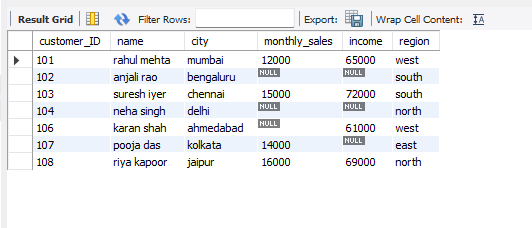

 TASKS
 ## 1) Identify affected rows

In [ ]:
select* FROM customer_profile
WHERE REGION IS NULL;

## OUTPUT
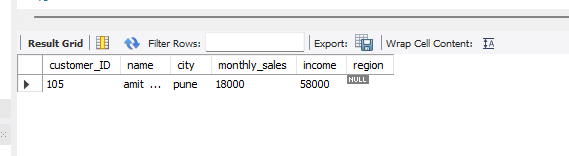

# 2) Show the dataset after deletion

In [ ]:
delete FROM customer_profile
WHERE REGION IS NULL;
select* FROM customer_profile;

## OUTPUT
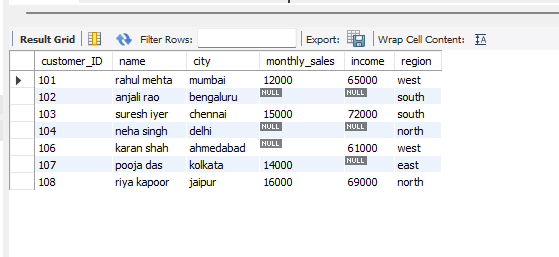

# 3) Mention how many records were lost

 WE LOST 1 DATA AFTER DELETING  DATA

# Q9. Imputation

Handle missing values in Monthly_Sales using:

Forward Fill

Tasks:

1) Apply forward fill

In [ ]:
UPDATE customer_profile
SET MONTHLY_SALES=12000
WHERE customer_ID=102;
UPDATE customer_profile
SET MONTHLY_SALES=15000
WHERE customer_ID=104;
UPDATE customer_profile
SET MONTHLY_SALES=18000
WHERE customer_ID=106;
select customer_ID, MONTHLY_SALES
FROM customer_profile;

## OUTPUT
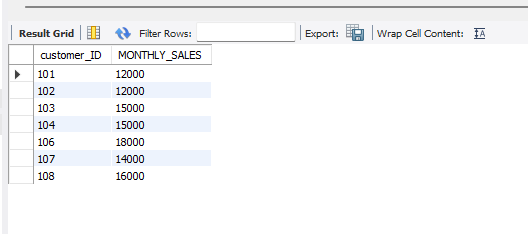

2) Show before vs after values

# BEFORE Apply forward fill
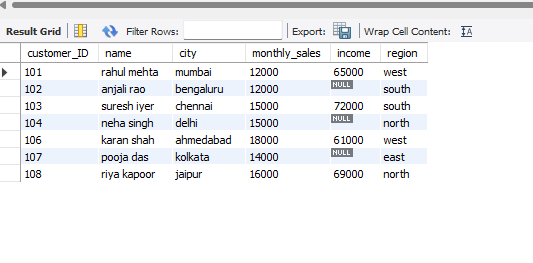

# AFTER Apply forward fill
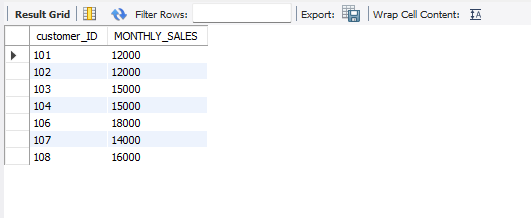

# 3) Explain why forward fill is suitable here



### ANSWER
Forward Fill replaces missing Monthly_Sales values with the previous available value. It is suitable for ordered or time-series data because it preserves continuity and avoids leaving missing values.

Q10. Flagging Missing Data

Create a flag column for missing Income.

Tasks:

1) Create Income_Missing_Flag (0 = present, 1 = missing)


In [ ]:
UPDATE customer_profile
SET INCOME_MISSING_FLAG=
CASE
when INCOME IS NULL THEN 1
else 0
END;

2) Show updated dataset

In [ ]:
SELECT* FROM customer_profile;

### OUTPUT
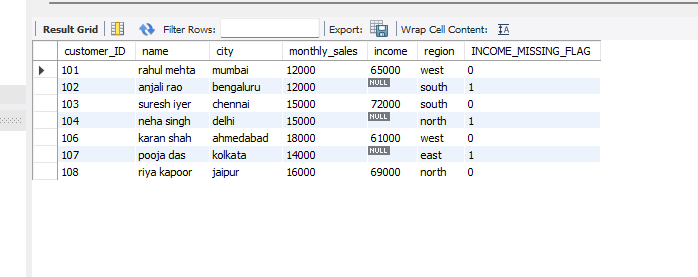

3) Count how many customers have missing income


In [ ]:
SELECT COUNT(*) AS Missing_Income_Count
FROM customer_profile
WHERE Income_Missing_Flag = 1;

## OUTPUT
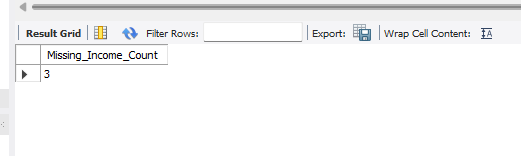

##